In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
def f(x):
    return 3*x**2 - 4*x + 5

In [ ]:
f(3.0)


20.0

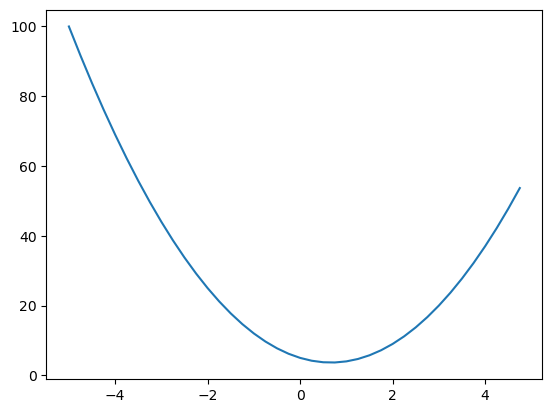

In [ ]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [ ]:
h = 0.00001
x = 2/3
(f(x+h)-f(x))/h


3.0000002482211127e-05

In [ ]:
# complex case
a = 2.0
b = -3.0
c = 10.0 
d = a*b + c
print(d)

4.0


In [ ]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0


d1 = a*b + c
c +=h
d2 = a*b+c
print("d1",d1)
print("d2",d2)
print('slope',(d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [ ]:
class Value:
    def __init__(self, data, _children = (),_op = '',label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"value(data = {self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data,(self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * self.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data,(self, other),'*') #here children is the tuple

        def _backward():
            self.grad += other.data * out.grad
            out.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__ (self, other): # it checks if self * other is possible instead of other * self
        return self * other 

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1- t**2) * out.grad
        out._backward = _backward
        
        return out 
    def exp(self):
        x = self.data
        out = Value(math.exp(x), label = 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
   
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        self.grad = 1.0
        build_topo(self)
        
        for node in reversed(topo):
            node._backward()

# Example
a = Value(2.0,label = 'a')
b = Value(-3.0,label ='b')
c = Value(10.0, label = 'c')

e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f ; L.label = 'L'
# (a.__mul__(b)).__add__(c)
L

value(data = -8.0)

In [ ]:
a = Value(2.0)
a.exp()


value(data = 7.38905609893065)

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
      
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


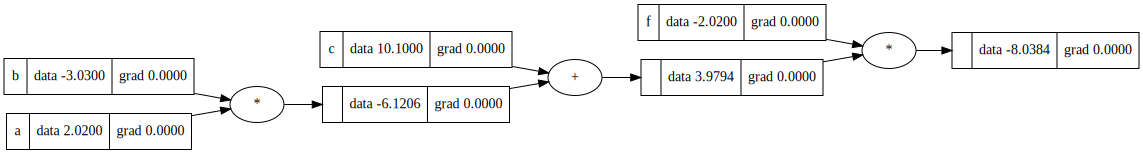

In [ ]:
draw_dot(L)

In [ ]:
L.grad = 1.0
f.grad = 4.0 # L = f* d then dL/df = d= 4.0
d.grad = -2.0
e.grad  = -2.0 
c.grad = -2.0
a.grad = 6.0 # -2 * -3
b.grad = -4.0 # -2 * 2

In [ ]:
a.data += 0.01* a.data
b.data += 0.01* b.data
c.data += 0.01* c.data
f.data +=0.01* f.data

e = a * b
d = e + c

L = d * f 
print(L)

value(data = -8.038388)


In [ ]:
def lol():
    h = 0.001
    a = Value(2.0,label = 'a')
    b = Value(-3.0,label ='b')
    c = Value(10.0, label = 'c')
    
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f ; L.label = 'L'
    # (a.__mul__(b)).__add__(c)
    L1 = L.data

    a = Value(2.0,label = 'a')
    b = Value(-3.0+h,label ='b')
    c = Value(10.0, label = 'c')
    
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f ; L.label = 'L'
    # (a.__mul__(b)).__add__(c)
    L2 = L.data 

    print((L2 - L1)/h)


lol()

-3.9999999999995595


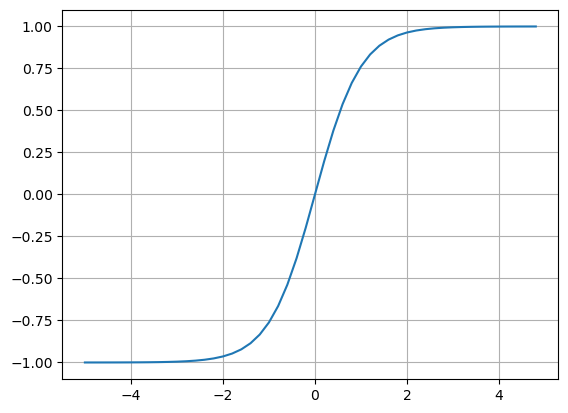

In [ ]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)))
plt.grid()

In [ ]:
#inputs
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#weights 
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# bias of the neuron
b = Value(6.8813735870195432, label = 'b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


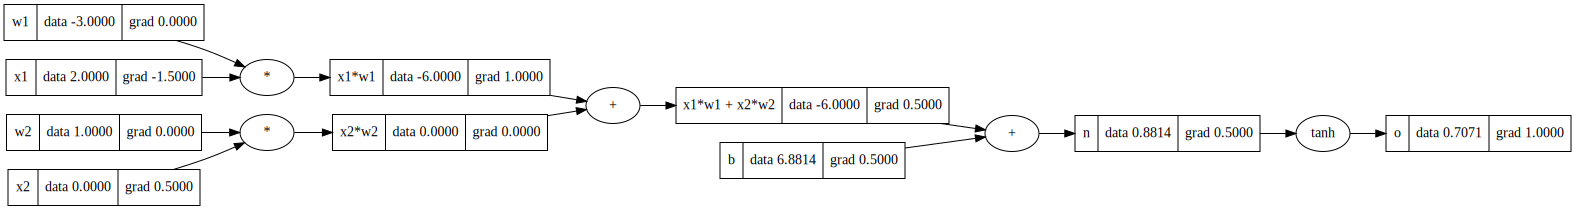

In [ ]:
draw_dot(o)


In [ ]:
o.backward()

In [ ]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[value(data = 6.881373587019543),
 value(data = 2.0),
 value(data = -3.0),
 value(data = -6.0),
 value(data = 1.0),
 value(data = 0.0),
 value(data = 0.0),
 value(data = -6.0),
 value(data = 0.8813735870195432),
 value(data = 0.7071067811865476)]

In [ ]:
o.grad =1.0

In [ ]:
o._backward()

In [ ]:
n._backward()

In [ ]:
b._backward()

In [ ]:
x1w1x2w2._backward()


In [ ]:
x1w1._backward()
x2w2._backward()

In [ ]:
o.grad = 1.0
n.grad = 1 - o.data **2
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = w1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad

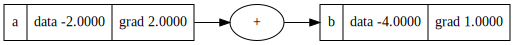

In [ ]:
a = Value(-2.0, label = 'a')
b = a + a ; b.label = 'b'
b.backward()
draw_dot(b)

